# Multilayer perceptron: A simple regression problem

## Dataset: Independent Volcanic Eruption Source Parameter Archive (IVESPA)

![](https://www.ivespa.co.uk/images/logos/IVESPA_logo_1.jpg)

The Independent Volcanic Eruption Source Parameter Archive (IVESPA) is an online archive of published volcano eruption information relevant for informing development and validation of eruption column models and empirical relations of eruption plume height and mass eruption rate. Version 1.0 contains independent eruption source parameter information for 134 eruptive events, and available for download [here][ivespa].

[ivespa]: https://www.ivespa.co.uk/ "IVESPA dataset"

## Exploring dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fname = "data/IVESPAvn1.0.csv"
df = pd.read_csv(fname)
df

,Volcano,Latitude,Longitude,Vent altitude,Year,Duration,TEM,Plume top height,Wind NOAA,Brunt-Väisälä frequency NOAA,Wind shear NOAA,Wind speed ERA,Brunt-Väisälä frequency ERA,Wind shear ERA
0,Agung,-8.343,115.508,3142,1963,5.2500,3.740000e+11,13.0,10.082076,0.010783,0.001940,3.571636,0.010003,0.000513
1,Agung,-8.343,115.508,3142,1963,4.5000,3.540000e+11,13.0,8.186314,0.010612,0.001343,8.762418,0.010028,0.001564
2,Anatahan,16.350,145.670,0,2003,35.0000,2.930000e+10,8.0,5.437572,0.011969,0.000786,6.436519,0.011967,0.001061
3,Anatahan,16.350,145.670,0,2003,48.0000,9.250000e+09,2.5,2.798929,0.011524,0.001860,3.230936,0.011852,0.001914
4,Augustine,59.363,-153.430,1252,2006,0.0697,1.730000e+09,13.5,4.372798,0.015210,0.000612,5.993524,0.015298,0.000760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,Tungurahua,-1.467,-78.442,5023,2006,5.0000,2.490000e+10,16.0,5.855170,0.010954,0.000646,6.192126,0.010114,0.000746
126,Tungurahua,-1.467,-78.442,5023,2013,1.0000,6.720000e+08,11.4,7.209165,0.010044,0.001788,8.735809,0.010338,0.002128
127,Tungurahua,-1.467,-78.442,5023,2014,0.4300,5.400000e+09,13.7,5.087269,0.009961,0.000833,5.785914,0.009343,0.001147
128,Tyatya,44.353,146.252,500,1973,96.0000,2.600000e+11,8.0,13.745128,0.013319,0.003429,16.355454,0.013083,0.003951


<Axes: >

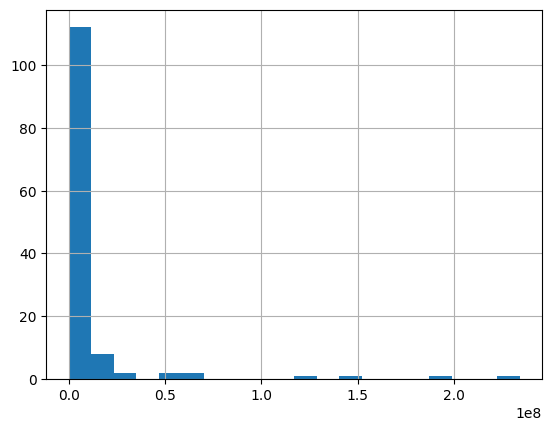

In [2]:
# Compute mass emission rate in kg/s
df['MER'] = df['TEM']/(df['Duration']*3600)
df = df.sort_values("MER")
df['MER'].hist(bins=20)

<Axes: >

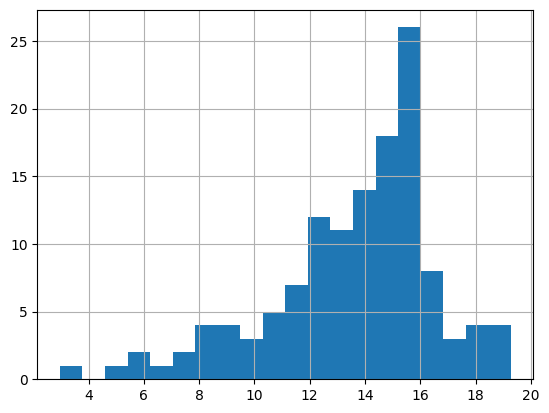

In [3]:
# Apply a log transformation to define out target
df['target'] = np.log(df['MER'])
df['target'].hist(bins=20)

## Empirical expressions for column top height

Mastin et al. (2009) proposed the following empirical expression for the dependency of the column top height on the mass eruption rate (MER):

$ H = 0.304 \times MER^{0.241}$

where $H$ is the height in km above vent level and $MER$ has units of $kg~s^{-1}$

<Axes: xlabel='Mass eruption rate ($kg~s^{-1}$)', ylabel='Column top heigth [km avl]'>

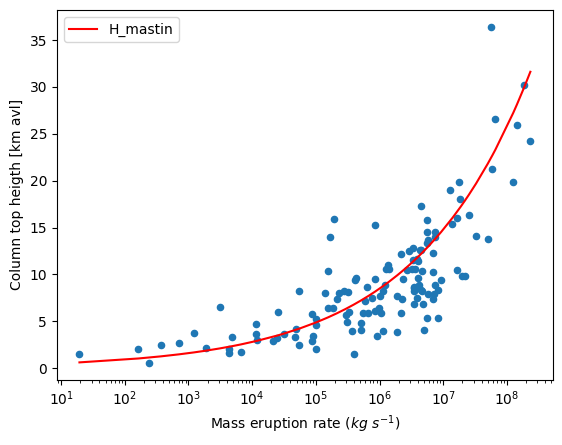

In [4]:
# Column height above the vent in km
df['Vent altitude'] *= 1E-3 # re-scale m->km
df['H'] = df['Plume top height'] - df['Vent altitude']

# Empirical expression by Mastin et al. (2009)
df['H_mastin'] = 0.304 * df['MER']**0.241

ax = df.plot(
    x = 'MER', y = 'H_mastin', 
    color = 'r',
    logx = True)

df.plot.scatter(
    x = 'MER', y = 'H', 
    xlabel='Mass eruption rate ($kg~s^{-1}$)',
    ylabel='Column top heigth [km avl]',
    ax=ax)

# Training a multilayer perceptron

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split

In [6]:
### Configuration ###
BATCH_SIZE    = 16
LEARNING_RATE = 1E-4
NUM_EPOCHS    = 3000
FNAME_MODEL   = 'regressor.pt'

In [7]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for X, y in loader:
        optimizer.zero_grad()
        prediction = model(X)
        loss = criterion(prediction,y)
        loss.backward()
        optimizer.step()
        
        # Get current batch size
        current_batch_size = X.size(0)
        total_loss += loss.item()*current_batch_size
    return total_loss / len(loader.dataset)

In [8]:
def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X, y in loader:
            prediction = model(X)
            loss = criterion(prediction,y)

            # Get current batch size
            current_batch_size = X.size(0)
            total_loss += loss.item()*current_batch_size
    return total_loss / len(loader.dataset)

## Preparing the dataset

In [39]:
# Selecting features
features = ['H', 'Vent altitude'] #, 'Wind NOAA',   , 'Brunt-Väisälä frequency NOAA'
#features = ['Vent altitude', 'Plume top height', 'Wind speed ERA', 'Brunt-Väisälä frequency ERA', 'Wind shear ERA']

nfeatures = len(features)

X = df[features].values.astype(np.float32)
y = df['target'].values.astype(np.float32)
X.shape, y.shape

((130, 2), (130,))

In [40]:
# Split arrays
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_val.shape

((104, 2), (26, 2))

Define a dataset class

In [41]:
class RegressionDataset(Dataset):
    def __init__(self, X, y, transform = None):
        """
        X: NumPy array of shape (n_samples, n_features)
        y: NumPy array of shape (n_samples, 1)
        """
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().unsqueeze(1)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform:
            x = self.transform(x)
        return x, self.y[idx]

Let's normalize our data

In [42]:
# Create a Transform Class for Normalization
class Normalize:
    def __init__(self, mean, std):
        self.mean = torch.from_numpy(mean).float()
        self.std  = torch.from_numpy(std).float()
        self.std[self.std == 0] = 1.0  # Avoid division by zero

    def __call__(self, x):
        return (x - self.mean) / self.std

    def invert(self, x):
        return (x * self.std + self.mean)

Create a training dataset and a validations dataset

In [43]:
# Compute normalization stats from training data only
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Define transform
transform = Normalize(mean, std)

# Datasets
train_dataset = RegressionDataset(X_train, y_train, transform=transform)
val_dataset   = RegressionDataset(X_val, y_val, transform=transform)

In [44]:
# Define dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Neural network model

In [45]:
# Define the model
class SimpleRegressor(nn.Module):
    def __init__(self, nfeatures, nhidden_1, nhidden_2):
        super(SimpleRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(nfeatures, nhidden_1),      # Input layer → hidden
            nn.ReLU(),
            nn.Dropout(p=0.1),
            ###
            nn.Linear(nhidden_1, nhidden_2),      # Hidden layer
            nn.ReLU(),
            #nn.Dropout(p=0.05),
            ###
            nn.Linear(nhidden_2, 1),              # Output layer
            nn.Softplus()                         # Ensures output is positive
        )

    def forward(self, x):
        return self.model(x)

In [46]:
# Instantiate model
model = SimpleRegressor(nfeatures, 32, 16)
summary(model, (nfeatures,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 32]              96
              ReLU-2                   [-1, 32]               0
           Dropout-3                   [-1, 32]               0
            Linear-4                   [-1, 16]             528
              ReLU-5                   [-1, 16]               0
            Linear-6                    [-1, 1]              17
          Softplus-7                    [-1, 1]               0
Total params: 641
Trainable params: 641
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


## Training loop

In [47]:
# Loss and optimizer
criterion = nn.MSELoss(reduction="mean")
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [48]:
train_losses = []
val_losses = []
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss   = evaluate_epoch(model, val_loader, criterion)
    # Store current losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if epoch%10 == 0 or epoch == NUM_EPOCHS-1:
        print(f"Epoch {epoch+1:02d} -> Train loss {train_loss:.4f} | Test loss: {val_loss:.4f}")

Epoch 01 -> Train loss 177.8186 | Test loss: 171.9300
Epoch 11 -> Train loss 176.9529 | Test loss: 171.0439
Epoch 21 -> Train loss 175.7905 | Test loss: 169.9764
Epoch 31 -> Train loss 174.2814 | Test loss: 168.6442
Epoch 41 -> Train loss 172.5720 | Test loss: 166.9360
Epoch 51 -> Train loss 170.1935 | Test loss: 164.7689
Epoch 61 -> Train loss 166.7025 | Test loss: 162.0027
Epoch 71 -> Train loss 163.1556 | Test loss: 158.4495
Epoch 81 -> Train loss 157.9831 | Test loss: 153.8186
Epoch 91 -> Train loss 151.4250 | Test loss: 148.0220
Epoch 101 -> Train loss 143.2693 | Test loss: 141.0208
Epoch 111 -> Train loss 135.4259 | Test loss: 132.7277
Epoch 121 -> Train loss 125.0563 | Test loss: 123.1139
Epoch 131 -> Train loss 112.9781 | Test loss: 112.6511
Epoch 141 -> Train loss 103.7396 | Test loss: 102.0634
Epoch 151 -> Train loss 92.4034 | Test loss: 91.5241
Epoch 161 -> Train loss 81.1511 | Test loss: 81.2748
Epoch 171 -> Train loss 71.6067 | Test loss: 71.5822
Epoch 181 -> Train loss 62

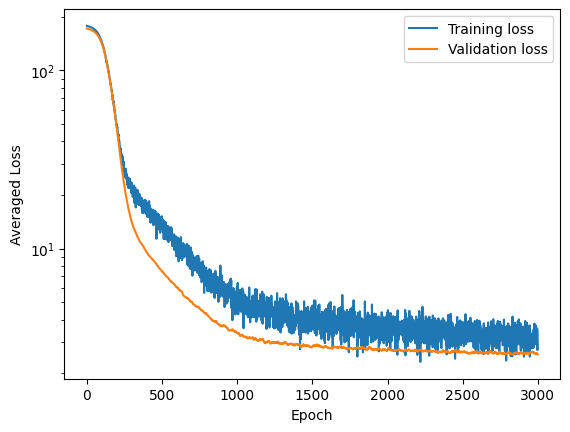

In [49]:
fig, ax = plt.subplots()

ax.plot(train_losses, label = 'Training loss')
ax.plot(val_losses, label = 'Validation loss')
ax.set(xlabel= "Epoch", ylabel= "Averaged Loss", yscale="log")
ax.legend()
#plt.set_yscale('log')

In [50]:
model.eval()

#ax = df.plot.scatter(x='Plume top height', y='MER', logy=True)

#h = np.linspace(0,40,100)
#mastin = 140.8 * h**4.15
#ax.plot(h, mastin, 'g-')

heights = []
emission_raters = []
targets = []
with torch.no_grad():
    for X, y in val_loader:
        prediction = model(X)
        xx = transform.invert(X)
        heights.append(xx[:,0])
        emission_raters.append(prediction.squeeze())
        targets.append(y.squeeze())
h  = torch.cat(heights)
yp = torch.cat(emission_raters)
y  = torch.cat(targets)

In [51]:
criterion(yp,y)

tensor(2.5490)

In [52]:
ym = 140.8 * h**4.15
ym = torch.log(ym)
criterion(ym,y)

tensor(3.6730)

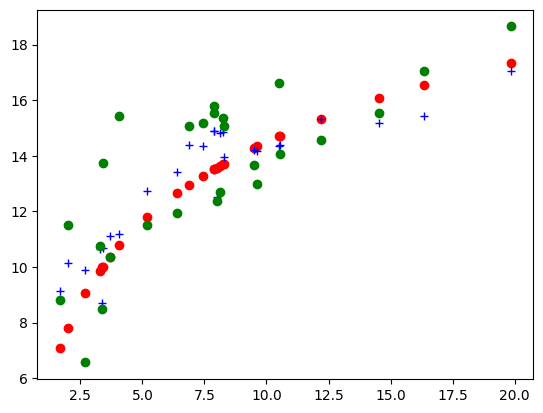

In [53]:
fig, ax = plt.subplots()

ax.plot(h,ym, 'ro')
ax.plot(h,yp, 'b+')
ax.plot(h,y, 'go')
#ax.set_yscale('log')

In [71]:
NSAMPLES = 40
col1 = torch.linspace(1, 20, NSAMPLES, dtype=torch.float32)
col2 = torch.full((NSAMPLES,), 6, dtype=torch.float32)
X = torch.stack((col1, col2), dim=1)
y = torch.full((NSAMPLES,1), 0, dtype=torch.float32)

X = transform(X)

#dataset = RegressionDataset(X, y, transform=transform)

model.eval()
with torch.no_grad():
    yp = model(X)



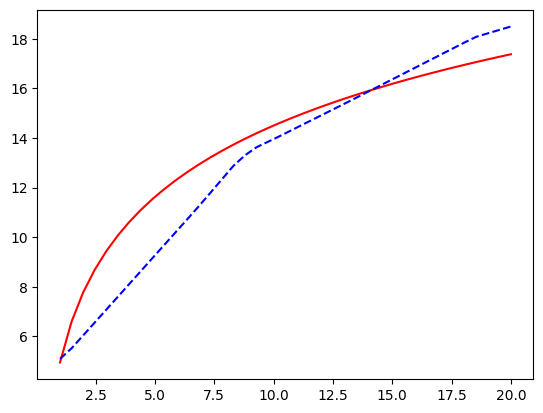

In [72]:
fig, ax = plt.subplots()

ym = 140.8 * col1**4.15
ym = torch.log(ym)

ax.plot(col1,ym, 'r-')
ax.plot(col1, yp.detach().numpy(), 'b--')
#ax.plot(h,y, 'go')
